# **Домашнее задание: Backpropagation**

В этом задании тебе нужно реализовать функционал для автоматического вычисления частных производных функций по параметрам --- метод backpropagation. После этого ты используешь свою реализацию для тренировки небольшой модели машинного обучения.

## **Импортируем библиотеки**

В этом задании мы не используем специализированных библиотек машинного обучения: весь функционал будет реализован на Bare Python.

In [153]:
import math
import random
from pickletools import optimize

# Единственная специализированная библиотека, которая нам понадобится это graphviz
# с ее помощью мы сможем строить красивые визуализации графов вычислений
from graphviz import Digraph
from IPython.display import Image

В следующем блоке реализован функционал для построения графа вычислений.

In [154]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## **Идея метода backpropagation**

Рассмотрим произвольную сложную функцию многих переменных. Например,

$$L = d \cdot (c + a \cdot b).$$

Для такой простой функции мы можем легко подсчитать значение частных производных $\frac{\partial L}{\partial a}, \frac{\partial L}{\partial b}, \frac{\partial L}{\partial c}, \frac{\partial L}{\partial d}$ в любой точке. Но если функция окажется более громоздкой, то независимое вычисление каждой производной окажется трудоемким делом.

В этом разделе мы познакомимся с методом **backpropagation**: важнейшим компонентом успеха глубокого обучения. Этот метод даст нам эффективный способ быстрого вычисления всех частных производных функции по своим аргументам.

### Граф вычислений 

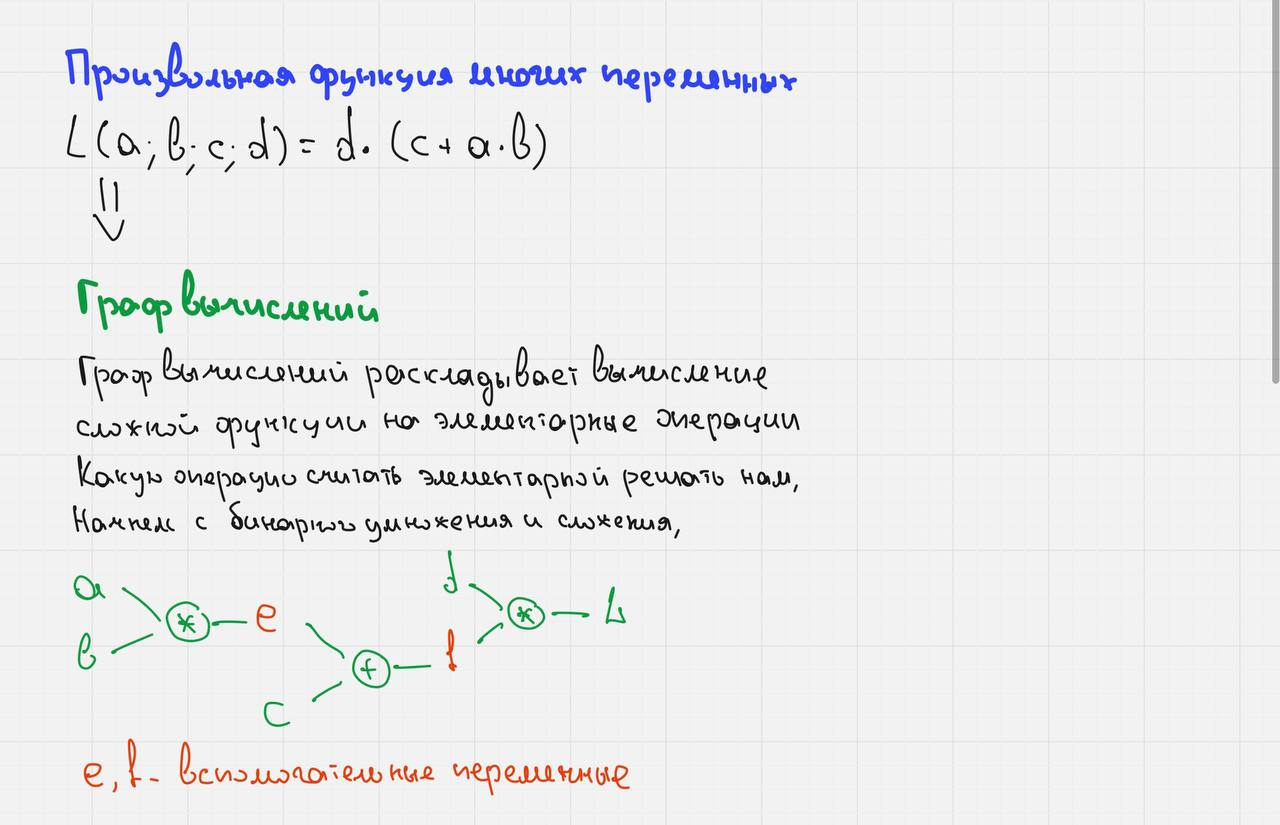

In [155]:
Image(filename='backprop1.jpg')

### **Идея 2: Итеративное вычисление частных производных**

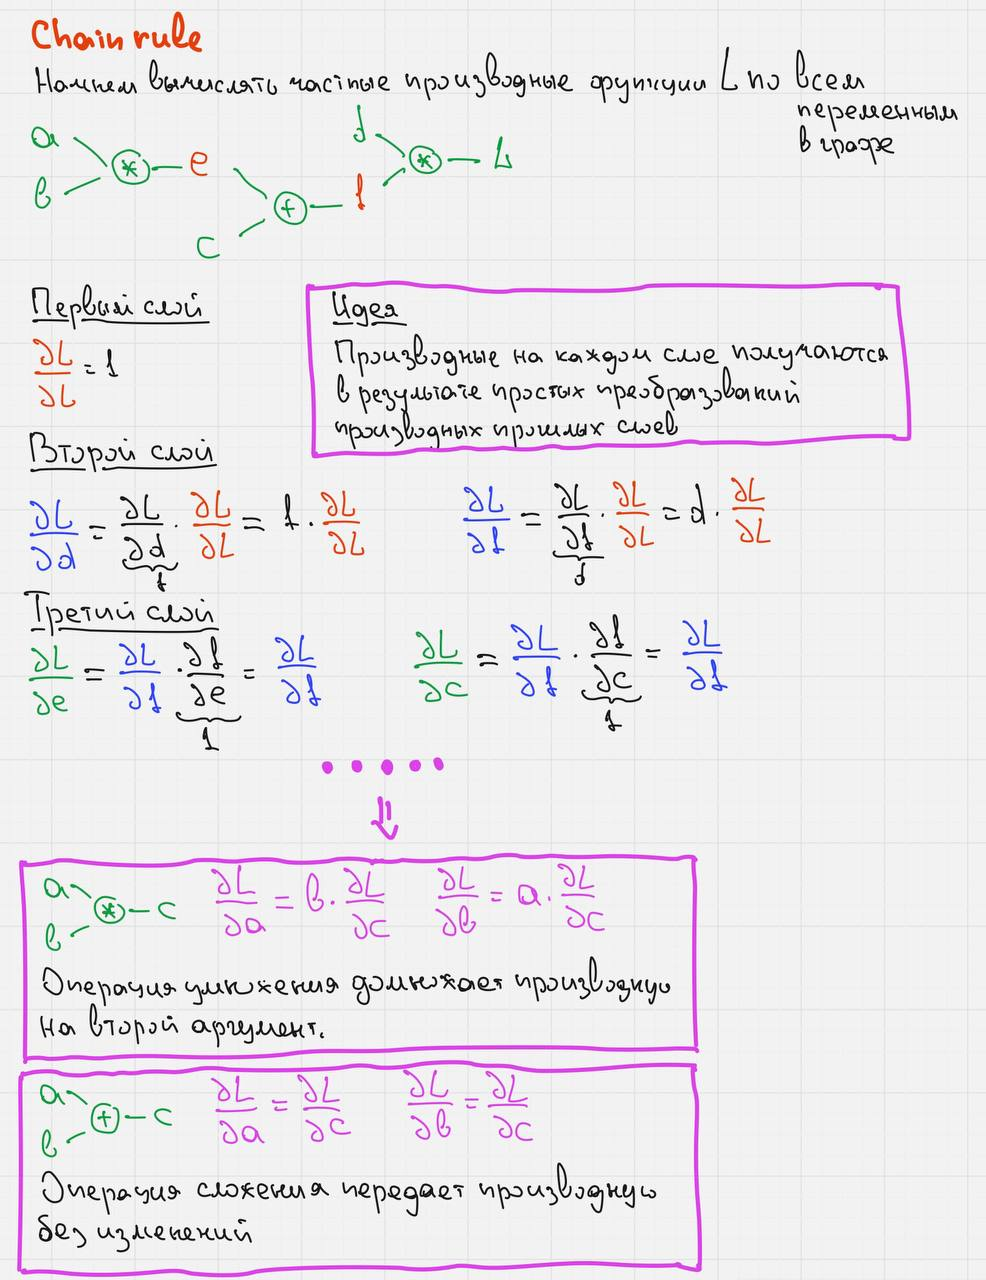

In [156]:
Image(filename='backprop2.jpg')

### **Summary: Автоматическое дифференцирование**

Объединяя две идеи, получим простой и элегантный способ автоматического дифференцирования. Для произвольной сложной функции многих переменных $f$ мы сначала строим граф ее вычислений, а затем вычисляем значения всех частных производных, начиная с тождества $\frac{\partial f}{\partial f} = 1$ и распространяя его по слоям справа налево.

---

Главный вопрос, на который нам осталось ответить: <font color='DarkOrange'>**Как научиться строить граф вычислений?**</font>

В этом задании ты познакомишься с простым и элегантным решением. Тебе нужно будет реализовать собственный класс для чисел (расширение стандартного `float`), который мы будем называть `Value`. Как и стандартные числа `float`, объекты нашего класса будут иметь значения. Однако, у них будут дополнительные возможности:
- Каждое число будет помнить, из каких чисел и в результате каких операций оно получилось
- Каждой число будет уметь передавать значения частной производной числам, из которых оно получилось

## <font color='DarkOrange'>**Задание 1 [5 баллов]**</font>  

На лекции мы начали реализовывать класс `Value`. Тебе нужно продолжить реализацию и заполнить шаблон ниже.

Твое решение будет проверено на закрытых тестах, поэтому рекомендуем тебе проверить самостоятельно проверить свою реализацию на простых функциях.

In [157]:
class Value:

### Первая часть: то, что реализовали в классе

    def __init__(self, data, _children = (), _op = "", label=''):
        self.data = data               # значение числа
        self.grad = 0.0                # значение градиента
        self._prev = set(_children)    # числа, из которых получилось это число
        self._op = _op                 # операция, из которой получилось число
        self.label = label             # лейбл для отражения на графе
        self._backward = lambda: None  # функция передачи градиента в self._prev

    def __repr__(self):
        """Отображение числа внутри print"""
        return f"MyNumber({self.label}: {self.data})"

    def __add__(self, other):
        """Отображение сложения"""

        # Если складываем Value с обычным числом, нужно перевести обычное число
        # в Value
        other = other if isinstance(other, Value) else Value(other)

        # Результат сложения
        out = Value(self.data + other.data, _children = (self, other), _op="+")

        # Объясняем out как передать частные производные в self и other
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        """Поддерживаем операцию вида float + value"""
        return self + other

    def __mul__(self, other):
        """Отображение умножения"""
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children = (self, other), _op="*")

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward = _backward

        return out

    def __rmul__(self, other):
        """Поддерживаем операцию вида float * value"""
        return self * other

    def backward(self):
        """Вычисляем частные производные self по всему графу вычислений"""

        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
          node._backward()



### Вторая часть: то, что нужно реализовать тебе

    def __pow__(self, other):
        """Возведение self в степень other"""

        assert isinstance(other, (int, float)) # разрешаем возведение в степени вида int и float
        other = Value(other, label=str(other))
        out = Value(self.data ** other.data, _children=(self, other), _op='^', label=f'{self.label}^{other.data}')

        def _backward():
            self.grad += out.grad * other.data * self.data ** (other.data - 1)

        out._backward = _backward

        return out

    def __truediv__(self, other):
        """Деление self на other"""
        other = other if isinstance(other, Value) else Value(other)
        assert other.data != 0
        out = self * other ** -1
        return out

    def __rtruediv__(self, other):
        return other * (self**-1)

    def __neg__(self):
        """Вычисление отрицания (умножение на -1)"""
        out = self * -1
        out._op='*-1'
        return out

    def __sub__(self, other):
        """Вычитание other из self"""
        out = self + other * -1
        return out

    def tanh(self):
        """Поддерживаем функцию tanh"""
        out = (self.exp() - (-self).exp()) / (self.exp() + (-self).exp())
        return out

    def ReLU(self):
        """Поддерживаем функцию ReLU"""
        out = Value(self.data if self.data >= 0 else 0, _op='ReLU')
        def _backward():
            self.grad += out.grad * (1 if out.data >= 0 else 0)
        out._backward = _backward
        return out

    def exp(self):
        """Поддерживаем функцию exp"""
        _exp_value = math.exp(self.data)
        out = Value(data=_exp_value, _children=(self, ), _op='exp')
        def _backward():
            self.grad += out.grad * _exp_value
        out._backward = _backward
        return out

    def log(self):
        out = Value(data=math.log(self.data), _children=(self, ), _op='log')

        def _backward():
            self.grad += out.grad * (1 / self.data)
        out._backward = _backward
        return out

    def sigmoid(self):
        """Поддерживаем сигмоиду"""
        out = 1 / (1 + (-self).exp())
        return out

#### **Иллюстрация работы класса Value**

Исполни ячейку ниже, чтобы посмотреть, как выглядит граф вычислений и как вычисляются частные производные на примере простой функции.

$$L = (a + b) \cdot e$$

In [158]:
# Представляем вычисление функции L через элеменетарные операции
a = Value(5, label='a')
b = Value(7, label='b')
b = b ** 2
c = a / b; c.label = "c"

e = Value(0.5, label='e')

L = c * e; L.label = "L"

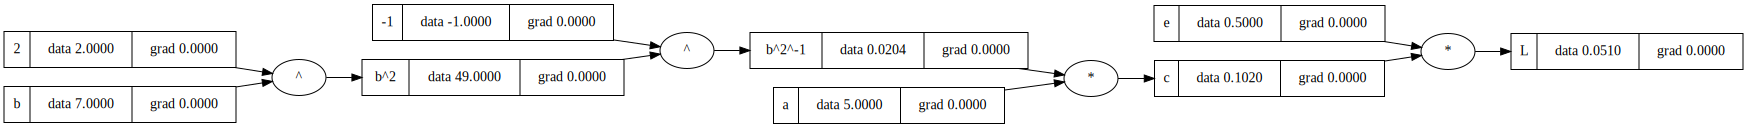

In [159]:
# Строим граф вычислений
draw_dot(L)

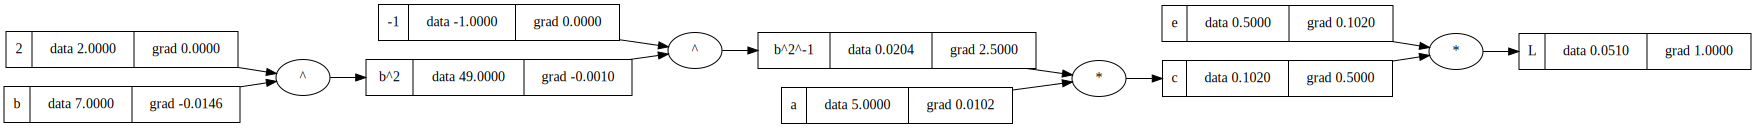

In [160]:
# Вычисляем производные и отображаем их на графе
L.backward() 
draw_dot(L)

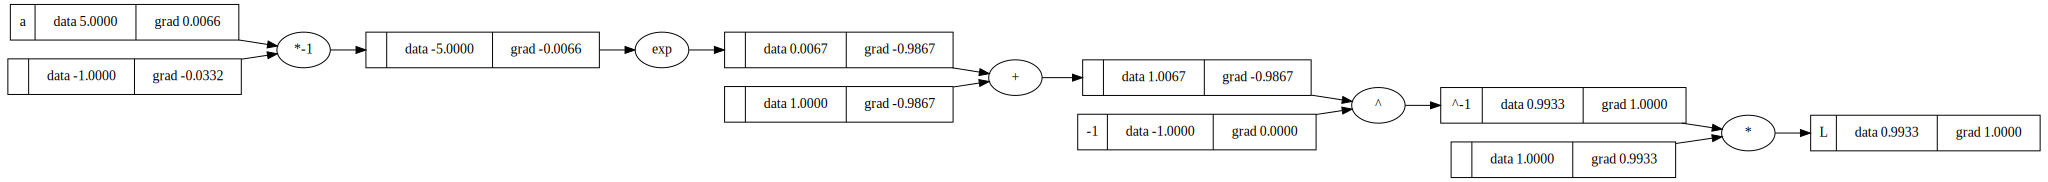

In [161]:
# Представляем вычисление функции L через элеменетарные операции
a = Value(5, label='a')
# b = Value(7, label='b')
L = a.sigmoid()
L.label = "L"
# Строим граф вычислений
draw_dot(L)
# Вычисляем производные и отображаем их на графе
L.backward()
draw_dot(L)

## <font color='DarkOrange'>**Задание 2 [5 баллов]**</font>  

Реализуй модель логистической регрессии и попробуй применить ее к реальному датасету классификации с небольшим количеством фичей. Ты можешь взять любой датасет на Kaggle или из репозитария UCI. Если реальные датасеты окажутся слишком большими для твоей модели, ты можешь создать свой синтетический датасет и обучить модель на нем.

In [162]:
import pandas as pd
import numpy as np
df = pd.read_csv('Classification_dataset.csv')
df.head()

,age,income,will_buy
0,25,30000,0
1,35,40000,1
2,45,60000,1
3,30,35000,0
4,50,80000,1


In [163]:
X = np.array(df[['age', 'income']])
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X = np.concat([np.ones([X.shape[0], 1]), X], axis=1)
y = np.array(df['will_buy'])

In [164]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)
betas = np.array([Value(1) for _ in range(X.shape[1])])
N = X_train.shape[0]
lr = 1e-3
for epoch in range(1000):
    dotproduct = X_train @ betas
    logits = [logit.sigmoid().log() for logit in dotproduct]
    mlogits = [(-logit.sigmoid() + 1).log() for logit in dotproduct]

    L = - 1 / N * (y_train @ logits + (1 - y_train) @ mlogits)
    L.backward()

    for i in range(len(betas)):
        betas[i].data -= lr * betas[i].grad
        betas[i].grad = 0

In [165]:
dotproduct = X_test @ betas
probs = [logit.sigmoid().data for logit in dotproduct]
probs

[0.4449237582476559,
 0.6267683649379262,
 0.9879884901460269,
 0.2790306948526297,
 0.8586366512443864,
 0.3726815672498423,
 0.9838615142610785,
 0.357728072149079,
 0.9784947656760375,
 0.9421395566917878,
 0.5961287091077322,
 0.9756055242877486,
 0.34304646721185383,
 0.49020513292465484,
 0.9865109525201088,
 0.2790306948526297,
 0.9187947857677083,
 0.14907737621814104,
 0.954202492344875,
 0.9031352954300056,
 0.2684942896297797,
 0.77668474079298,
 0.8735843907951301,
 0.7982620719331424]

In [166]:
y_pred = [1 if prob > 0.5 else 0 for prob in probs]
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9166666666666666